# Phase 3 - Classification: battery health (ANN)

Non-linear classifier: an ANN (MLP) trained by backpropagation, predicting the
cycle's health_class.

To control overfitting the network is kept small, L2-regularised (`alpha`), and
uses early stopping (training halts when validation stops improving, so it cannot
memorise the training data)

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("/kaggle/input/datasets/marryammohammed/nasa-battery-cycle-level-dataset/NASA Battery Cycle Level Dataset.csv")
print("rows, cols:", df.shape)
print(df["health_class"].value_counts())

rows, cols: (2769, 59)
health_class
Healthy     1476
Degraded    1293
Name: count, dtype: int64


In [2]:
data = df[df["SOH"] > 0.1].reset_index(drop=True)

id_cols = ["source_file", "battery_id", "test_id", "uid", "start_time"]
target_cols = ["Capacity", "SOH", "SOH_relative", "initial_capacity",
               "RUL_cycles", "health_class"]

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feat = [c for c in num_cols if c not in id_cols + target_cols]
feat = [c for c in feat if data[c].notna().any() and data[c].std() > 0]
data[feat] = data[feat].fillna(data[feat].median(numeric_only=True))
print("number of features:", len(feat))

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X = data[feat].to_numpy(dtype=float)
y = le.fit_transform(data["health_class"].astype(str))
groups = data["battery_id"].to_numpy()
class_names = list(le.classes_)
print("classes:", class_names)

number of features: 44
classes: ['Degraded', 'Healthy']


In [3]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold

sp = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr, te = next(sp.split(X, y, groups))
X_train, X_test = X[tr], X[te]
y_train, y_test = y[tr], y[te]
g_train = groups[tr]

cv = GroupKFold(n_splits=min(5, len(set(g_train))))
print("train rows:", len(y_train), "| test rows:", len(y_test))

train rows: 2237 | test rows: 326


In [4]:
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

results = []

def evaluate(name, model, cv_acc):
    tr_acc = accuracy_score(y_train, model.predict(X_train))
    pred = model.predict(X_test)
    te_acc = accuracy_score(y_test, pred)
    print(name)
    print("  train acc = %.4f | CV acc = %.4f | test acc = %.4f | misclassification = %.4f"
          % (tr_acc, cv_acc, te_acc, 1 - te_acc))
    print(classification_report(y_test, pred, labels=np.arange(len(class_names)),
                                target_names=class_names, zero_division=0))
    cm = confusion_matrix(y_test, pred, labels=np.arange(len(class_names)))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues")
    plt.title(name); plt.tight_layout(); plt.show()
    results.append({"model": name, "train_acc": tr_acc, "CV_acc": cv_acc,
                    "test_acc": te_acc, "misclass_rate": 1 - te_acc})

## ANN (MLP) - regularised
Small hidden layer + larger alpha + early stopping. Hidden size and alpha are chosen
by grouped cross-validation.

best ANN params: {'mlpclassifier__alpha': 0.1, 'mlpclassifier__hidden_layer_sizes': (5,)}
ANN (MLP)
  train acc = 0.9566 | CV acc = 0.9156 | test acc = 0.9356 | misclassification = 0.0644
              precision    recall  f1-score   support

    Degraded       0.88      0.97      0.92       127
     Healthy       0.98      0.91      0.95       199

    accuracy                           0.94       326
   macro avg       0.93      0.94      0.93       326
weighted avg       0.94      0.94      0.94       326



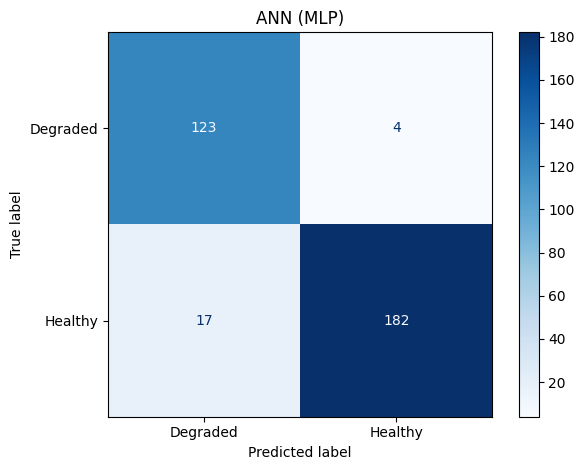

In [5]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

ann_search = GridSearchCV(
    make_pipeline(StandardScaler(),
                  MLPClassifier(max_iter=1000, early_stopping=True,
                                n_iter_no_change=15, random_state=42)),
    {"mlpclassifier__hidden_layer_sizes": [(5,), (10,)],
     "mlpclassifier__alpha": [0.1, 1, 10, 100]},
    cv=cv, scoring="accuracy", n_jobs=-1)
ann_search.fit(X_train, y_train, groups=g_train)
ann = ann_search.best_estimator_
print("best ANN params:", ann_search.best_params_)
evaluate("ANN (MLP)", ann, ann_search.best_score_)

In [11]:
check = pd.DataFrame(results).set_index("model").round(4)
print(check[["train_acc", "CV_acc", "test_acc"]])
print()
for name, r in check.iterrows():
    tr_cv = r["train_acc"] - r["CV_acc"]
    cv_te = r["CV_acc"] - r["test_acc"]
    if r["train_acc"] < 0.8:
        v = "underfits (bias)"
    elif tr_cv > 0.05:
        v = "some overfitting (train >> CV)"
    elif cv_te > 0.05:
        v = "balanced in CV"
    else:
        v = "balanced - no overfitting"
    print("%-12s -> %s" % (name, v))

           train_acc  CV_acc  test_acc
model                                 
ANN (MLP)     0.9566  0.9156    0.9356

ANN (MLP)    -> balanced - no overfitting


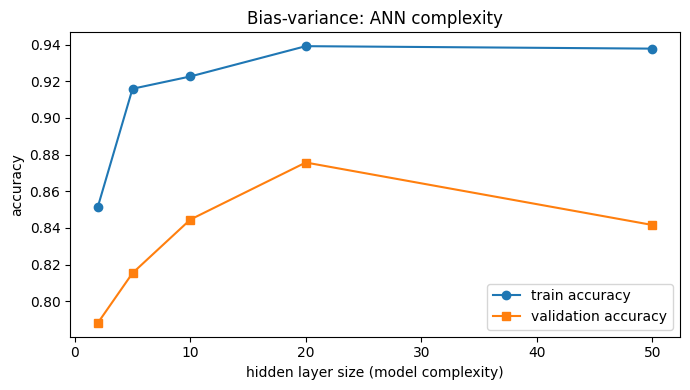

In [7]:
from sklearn.model_selection import cross_val_score

sizes = [2, 5, 10, 20, 50]
train_acc, val_acc = [], []
for s in sizes:
    pipe = make_pipeline(StandardScaler(),
                         MLPClassifier(hidden_layer_sizes=(s,), alpha=10,
                                       early_stopping=True, max_iter=1000, random_state=42))
    val_acc.append(cross_val_score(pipe, X_train, y_train, groups=g_train,
                                   cv=cv, scoring="accuracy").mean())
    pipe.fit(X_train, y_train)
    train_acc.append(pipe.score(X_train, y_train))

plt.figure(figsize=(7, 4))
plt.plot(sizes, train_acc, "o-", label="train accuracy")
plt.plot(sizes, val_acc, "s-", label="validation accuracy")
plt.xlabel("hidden layer size (model complexity)")
plt.ylabel("accuracy")
plt.title("Bias-variance: ANN complexity")
plt.legend(); plt.tight_layout(); plt.show()

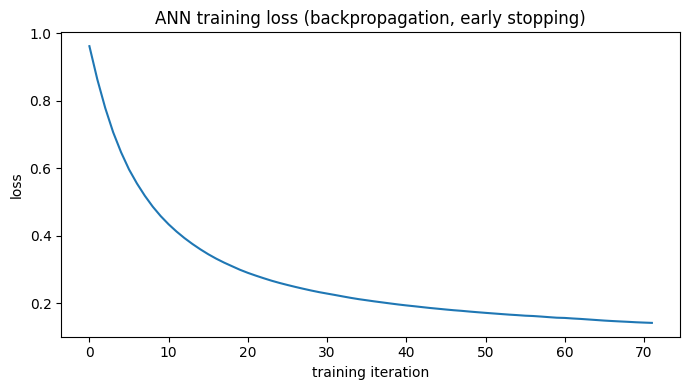

In [8]:
mlp = ann.named_steps["mlpclassifier"]
plt.figure(figsize=(7, 4))
plt.plot(mlp.loss_curve_)
plt.xlabel("training iteration")
plt.ylabel("loss")
plt.title("ANN training loss (backpropagation, early stopping)")
plt.tight_layout(); plt.show()

In [9]:
summary = pd.DataFrame(results).set_index("model").round(4)
print(summary)

           train_acc  CV_acc  test_acc  misclass_rate
model                                                
ANN (MLP)     0.9566  0.9156    0.9356         0.0644
